In [1]:
import tensorflow as tf
print(tf.__version__)

2.18.0


(429, 640, 3)
(1, 429, 640, 3)


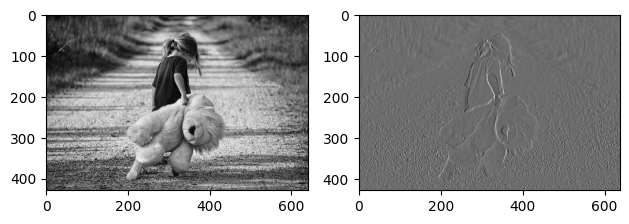

In [ ]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import matplotlib.image as img

fig = plt.figure()
ax1 = fig.add_subplot(1,2,1)
ax2 = fig.add_subplot(1,2,2)

# image data loading
ori_image = img.imread('/content/girl.jpg')
# print(type(ori_image))  # <class 'numpy.ndarray'>
print(ori_image.shape)  # (429, 640, 3)

# tensorflow가 제공하는 함수를 이용해서 conv 연산을 수행
# 입력이미지의 형태
# (1, 429, 640, 3) => (이미지 개수, height, width, channel )
input_image = ori_image.reshape((1,) + ori_image.shape)
print(input_image.shape) # (1, 429, 640, 3)
input_image = input_image.astype(np.float32)

# 흑백이미지도 원래는 3차원이예요!(channel이 3인)
# 흑백이미지는 1개의 channel을 이용해서 3차원으로 표현이 가능!~
# 입력이미지의 channel을 변경
# (1, 429, 640, 1)
input_image_1_channel = input_image[:,:,:,0:1]
# input_image_1_channel.shape # (1, 429, 640, 1)

# Filter(Kernel) 준비
# (3, 3, 1, 1) => (height, width, filter channel, filter 개수)
# 이 filter는 기본적으로 랜덤을 기반으로 만들어져요!
# 그리고 지속적으로 갱신되서 점점 더 좋은 필터로 만들어지게 되요!
# filter = np.random.rand(3,3,1,1)
filter = np.array([[[[-1]],[[0]],[[1]]],
                   [[[-1]],[[0]],[[1]]],
                   [[[-1]],[[0]],[[1]]]])
# filter.shape # (3, 3, 1, 1)

# strides : 1
# padding : VALID(패딩 사용 X), SAME(패딩 사용)

# convolution 연산을 수행
conv2d = tf.nn.conv2d(input_image_1_channel,
                      filter,
                      strides=[1,1,1,1],
                      padding='VALID')
# 결과가 tensorflow 내부 자료구조인 tensor로 생성되요!
conv2d_result = conv2d.numpy()
conv2d_result.shape  # (1, 427, 638, 1)
# (이미지 개수, height, width, filter 개수)
t_img = conv2d_result[0,:,:,:]

ax1.imshow(ori_image)
ax2.imshow(t_img, cmap='gray')
plt.tight_layout()
plt.show()


(429, 640, 3)
(1, 429, 640, 3)


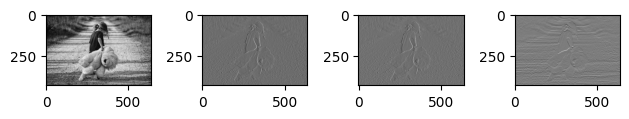

In [ ]:
# 필터를 3개 이용해서 3개의 feature map을 생성해서
# 결과를 확인해 보아요!

import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import matplotlib.image as img

fig = plt.figure()
ax1 = fig.add_subplot(1,4,1)
ax2 = fig.add_subplot(1,4,2)
ax3 = fig.add_subplot(1,4,3)
ax4 = fig.add_subplot(1,4,4)

# image data loading
ori_image = img.imread('/content/girl.jpg')
# print(type(ori_image))  # <class 'numpy.ndarray'>
print(ori_image.shape)  # (429, 640, 3)

# tensorflow가 제공하는 함수를 이용해서 conv 연산을 수행
# 입력이미지의 형태
# (1, 429, 640, 3) => (이미지 개수, height, width, channel )
input_image = ori_image.reshape((1,) + ori_image.shape)
print(input_image.shape) # (1, 429, 640, 3)
input_image = input_image.astype(np.float32)

# 흑백이미지도 원래는 3차원이예요!(channel이 3인)
# 흑백이미지는 1개의 channel을 이용해서 3차원으로 표현이 가능!~
# 입력이미지의 channel을 변경
# (1, 429, 640, 1)
input_image_1_channel = input_image[:,:,:,0:1]
# input_image_1_channel.shape # (1, 429, 640, 1)

# Filter(Kernel) 준비
# (3, 3, 1, 3) => (height, width, filter channel, filter 개수)
# 이 filter는 기본적으로 랜덤을 기반으로 만들어져요!
# 그리고 지속적으로 갱신되서 점점 더 좋은 필터로 만들어지게 되요!
filter = np.array([[[[-1,-1,-1]],[[0,0,-2]],[[1,1,-1]]],
                   [[[-1,-2,0]],[[0,0,0]],[[1,2,0]]],
                   [[[-1,-1,1]],[[0,0,2]],[[1,1,1]]]])
# filter.shape # (3, 3, 1, 3)

# strides : 1
# padding : VALID(패딩 사용 X), SAME(패딩 사용)

# convolution 연산을 수행
conv2d = tf.nn.conv2d(input_image_1_channel,
                      filter,
                      strides=[1,1,1,1],
                      padding='VALID')
# 결과가 tensorflow 내부 자료구조인 tensor로 생성되요!
conv2d_result = conv2d.numpy()
conv2d_result.shape  # (1, 427, 638, 3)
# (이미지 개수, height, width, filter 개수)
t_img_1 = conv2d_result[0,:,:,0]
t_img_2 = conv2d_result[0,:,:,1]
t_img_3 = conv2d_result[0,:,:,2]

ax1.imshow(ori_image)
ax2.imshow(t_img_1, cmap='gray')
ax3.imshow(t_img_2, cmap='gray')
ax4.imshow(t_img_3, cmap='gray')
plt.tight_layout()
plt.show()


(429, 640, 3)
(1, 429, 640, 3)


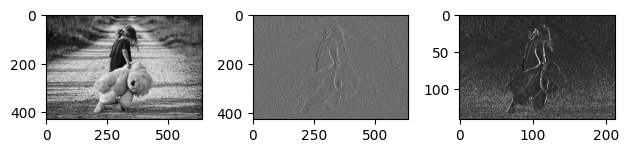

In [ ]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import matplotlib.image as img

fig = plt.figure()
ax1 = fig.add_subplot(1,3,1)
ax2 = fig.add_subplot(1,3,2)
ax3 = fig.add_subplot(1,3,3)

# image data loading
ori_image = img.imread('/content/girl.jpg')
# print(type(ori_image))  # <class 'numpy.ndarray'>
print(ori_image.shape)  # (429, 640, 3)

# tensorflow가 제공하는 함수를 이용해서 conv 연산을 수행
# 입력이미지의 형태
# (1, 429, 640, 3) => (이미지 개수, height, width, channel )
input_image = ori_image.reshape((1,) + ori_image.shape)
print(input_image.shape) # (1, 429, 640, 3)
input_image = input_image.astype(np.float32)

# 흑백이미지도 원래는 3차원이예요!(channel이 3인)
# 흑백이미지는 1개의 channel을 이용해서 3차원으로 표현이 가능!~
# 입력이미지의 channel을 변경
# (1, 429, 640, 1)
input_image_1_channel = input_image[:,:,:,0:1]
# input_image_1_channel.shape # (1, 429, 640, 1)

# Filter(Kernel) 준비
# (3, 3, 1, 1) => (height, width, filter channel, filter 개수)
# 이 filter는 기본적으로 랜덤을 기반으로 만들어져요!
# 그리고 지속적으로 갱신되서 점점 더 좋은 필터로 만들어지게 되요!
# filter = np.random.rand(3,3,1,1)
filter = np.array([[[[-1]],[[0]],[[1]]],
                   [[[-1]],[[0]],[[1]]],
                   [[[-1]],[[0]],[[1]]]])
# filter.shape # (3, 3, 1, 1)

# strides : 1
# padding : VALID(패딩 사용 X), SAME(패딩 사용)

# convolution 연산을 수행
conv2d = tf.nn.conv2d(input_image_1_channel,
                      filter,
                      strides=[1,1,1,1],
                      padding='VALID')
# 결과가 tensorflow 내부 자료구조인 tensor로 생성되요!
conv2d_result = conv2d.numpy()
conv2d_result.shape  # (1, 427, 638, 1)
# (이미지 개수, height, width, filter 개수)

# Pooling 처리
pool = tf.nn.max_pool(conv2d_result,
                      ksize=[1,3,3,1],
                      strides=[1,3,3,1],
                      padding='VALID')
pool_result = pool.numpy()


t_img1 = conv2d_result[0,:,:,:]
t_img2 = pool_result[0,:,:,:]

ax1.imshow(ori_image)
ax2.imshow(t_img1, cmap='gray')
ax3.imshow(t_img2, cmap='gray')
plt.tight_layout()
plt.show()


In [ ]:
# 원본 -> convolution -> pooling -> convolution -> pooling
# 그 결과를 출력해보세요!
# 원본에서 convolution을 이용해서 특징이 추출된 이미지를 많이 만들어요!
# 이런 이미지들에 대해서 각각 pooling처리를 진행
# 특징을 조금 더 강조하고 이미지의 사이즈를 줄일 수 있어요!
# 이미지의 사이즈를 줄여야 하는 이유 ->
# 이미지 1장이 결국 1차원으로 표현되어야 해요!
# 10x10 -> 1차원
# 3x3 -> 1차원
# 우리는 여러개의 convolution layer를 사용해요!
# 앞쪽(입력과 가까운쪽)의 convolution layer의 filter개수
# 뒤쪽의 convolution layer의 filter개수 -> 이게 더 많아야 해요!

In [ ]:
# MNIST를 CNN으로 구현해 보아요!
# 필요한 module import
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 데이터 전처리
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

# Model
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense
from tensorflow.keras.layers import Dropout, BatchNormalization
from tensorflow.keras.layers import Activation
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# 평가
from sklearn.metrics import classification_report

In [ ]:
# Raw Data Loading
df = pd.read_csv('/content/drive/MyDrive/KDTHome/[data]/MNIST/train.csv')
df.shape  # (42000, 785)

(42000, 785)

In [ ]:
# 1. 결측치와 이상치 처리 => 할게 없어요!
# feature engineering => 할게 없어요!

In [ ]:
# 독립변수와 종속변수 분리
x_data = df.drop('label', axis=1, inplace=False).values
t_data = df['label'].values.reshape(-1,1)

In [ ]:
# 학습데이터와 평가용 데이터 분리
x_data_train, x_data_test, t_data_train, t_data_test = \
train_test_split(x_data,
                 t_data,
                 test_size=0.3,
                 stratify=t_data,
                 random_state=42)

In [ ]:
# 정규화 진행 => x_data_train을 기준으로 정규화
scaler = MinMaxScaler()
scaler.fit(x_data_train)
x_data_train_norm = scaler.transform(x_data_train)
x_data_test_norm = scaler.transform(x_data_test)

In [ ]:
# Model 구현

model = Sequential()

model.add(Conv2D(filters=32,
                 kernel_size=(3,3),
                 activation='relu',
                 strides=(1,1),
                 input_shape=(28,28,1)))
# (None, 26, 26, 32)

model.add(Conv2D(filters=64,
                 kernel_size=(3,3),
                 activation='relu',
                 strides=(1,1)))
# (None, 24, 24, 64)

model.add(MaxPooling2D(pool_size=(2,2)))
# (None, 12, 12, 64)
model.add(Conv2D(filters=256,
                 kernel_size=(3,3),
                 activation='relu',
                 strides=(1,1)))
# (None, 10, 10, 256)
model.add(MaxPooling2D(pool_size=(2,2)))
# (None, 5, 5, 256)
##### Feature Extraction이 끝났어요! #####

model.add(Flatten())  # (None, 6400)
model.add(Dropout(rate=0.5)) # 오버피팅의 정도를 줄이기 위해
model.add(Dense(units=256,
                kernel_regularizer=l2(l2=0.1)))
model.add(BatchNormalization())
model.add(Activation('relu'))

model.add(Dense(units=10,
                activation='softmax'))

model.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 10, 10, 256)    │       147,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6400)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 6400)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     1,638,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,808,778 (6.90 MB)

 Trainable params: 1,808,266 (6.90 MB)

 Non-trainable params: 512 (2.00 KB)

In [ ]:
# 모델 설정
model.compile(optimizer=Adam(learning_rate=1e-4),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

es = EarlyStopping(monitor='val_loss',
                   patience=5,
                   verbose=1)

cp = ModelCheckpoint(filepath='/content/mnist.weights.h5',
                     save_best_only=True,
                     save_weights_only=True,
                     verbose=1,
                     monitor='val_loss')

In [ ]:
history = model.fit(x_data_train_norm.reshape(-1,28,28,1),
                    t_data_train,
                    epochs=100,
                    validation_split=0.2,
                    verbose=1,
                    batch_size=100,
                    callbacks=[es, cp])

Epoch 1/100
236/236 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.6808 - loss: 33.5726
Epoch 1: val_loss improved from inf to 6.85635, saving model to /content/mnist.weights.h5
236/236 ━━━━━━━━━━━━━━━━━━━━ 12s 25ms/step - accuracy: 0.6815 - loss: 33.5216 - val_accuracy: 0.9585 - val_loss: 6.8564
Epoch 2/100
232/236 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9637 - loss: 3.4742
Epoch 2: val_loss improved from 6.85635 to 0.90981, saving model to /content/mnist.weights.h5
236/236 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9637 - loss: 3.4464 - val_accuracy: 0.9679 - val_loss: 0.9098
Epoch 3/100
232/236 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9709 - loss: 0.4504
Epoch 3: val_loss improved from 0.90981 to 0.25812, saving model to /content/mnist.weights.h5
236/236 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9710 - loss: 0.4483 - val_accuracy: 0.9767 - val_loss: 0.2581
Epoch 4/100
232/236 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9772 - loss: 0.2226
Epoch 4: val_loss 

In [ ]:
import tensorflow as tf

print(tf.__version__)

2.18.0
